# 7DT Depth Analysis

## Image inspection methods

This notebook loads the authoritative 7DT+FINALCAT+SDSS master catalog, the detection image, and all 20 7DT single-band images. The methods below accept a catalog as a parameter and show catalog sources around a specified pixel center or around one randomly selected catalog source. Catalog coordinates use the FITS 1-based pixel convention used by `master_x` and `master_y`.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from astropy.visualization import ImageNormalize, ZScaleInterval

def project_root():
    cwd = Path.cwd().resolve()
    return cwd.parent if cwd.name == 'Notebooks' else cwd

PROJECT_ROOT = project_root()
COSMOS = 1
BANDS_7DT = [f'm{i}' for i in range(400, 900, 25)]
DATA_ROOT = PROJECT_ROOT / 'COSMOS_data'
MATCH_DIR = PROJECT_ROOT / f'output/COSMOS{COSMOS}/singlebandphot/matching'
MASTER_CATALOG_PATH = MATCH_DIR / 'master_catalog.fits'
master = Table.read(MASTER_CATALOG_PATH)
cat_7dt_only = master[master['master_class'] == '7dt_only']
cat_finalcat_only = master[master['master_class'] == 'finalcat_only']
cat_matched = master[master['master_class'] == 'matched']

detection_image_path = DATA_ROOT / f'COSMOS{COSMOS}/COSMOS{COSMOS}_detectionimage.fits'
detection_image = fits.getdata(detection_image_path, memmap=True)

def get_image_path(cosmos, band):
    paths = list((DATA_ROOT / f'COSMOS{cosmos}').glob(f'*{band}*.com.fits'))
    if len(paths) != 1:
        raise FileNotFoundError(f'Expected one COSMOS{cosmos} {band} image, found {len(paths)}')
    return paths[0]

band_images = {band: fits.getdata(get_image_path(COSMOS, band), memmap=True) for band in BANDS_7DT}
print(f'master catalog: {len(master)} rows')
print(f'loaded images: {len(band_images)} bands plus detection image')
print('master catalog data: ')
master[0:5].pprint(max_width=2000)

master catalog: 87236 rows
loaded images: 20 bands plus detection image
master catalog data: 
master_id master_class has_7dt has_finalcat n_7dt_bands position_origin      master_x           master_y         master_ra          master_dec           x_7dt              y_7dt             ra_7dt            dec_7dt          sigma_7dt_pix    m400_source_id  m400_mag m400_mag_err m400_ellipticity m400_flux_radius m425_source_id  m425_mag m425_mag_err m425_ellipticity m425_flux_radius m450_source_id  m450_mag m450_mag_err m450_ellipticity m450_flux_radius m475_source_id  m475_mag m475_mag_err m475_ellipticity m475_flux_radius m500_source_id  m500_mag  m500_mag_err m500_ellipticity m500_flux_radius m525_source_id  m525_mag m525_mag_err m525_ellipticity m525_flux_radius m550_source_id  m550_mag m550_mag_err m550_ellipticity m550_flux_radius m575_source_id  m575_mag m575_mag_err m575_ellipticity m575_flux_radius m600_source_id  m600_mag m600_mag_err m600_ellipticity m600_flux_radius m625_source_id 

## All-band depth configuration

Nearest SDSS band is chosen by central wavelength. Figures for all bands are saved under `output/COSMOS1/singlebandphot/matching/figures/depth_by_band`; only `m600` is displayed inline.


In [2]:
# All-band configuration: nearest SDSS band by central wavelength.
SDSS_CENTRAL_NM = {'u': 355.1, 'g': 468.6, 'r': 616.5, 'i': 748.1, 'z': 893.1}
BAND_CENTRAL_NM = {band: int(band[1:]) for band in BANDS_7DT}
# Nearest SDSS band for each 7DT band (ties -> shorter wavelength).
BAND_SDSS_MATCH = {}
for band, wav in BAND_CENTRAL_NM.items():
    BAND_SDSS_MATCH[band] = min(SDSS_CENTRAL_NM, key=lambda s: (abs(SDSS_CENTRAL_NM[s] - wav), s))
print('7DT -> nearest SDSS mapping:')
for band in BANDS_7DT:
    print(f'{band} ({BAND_CENTRAL_NM[band]} nm) -> SDSS {BAND_SDSS_MATCH[band]} ({SDSS_CENTRAL_NM[BAND_SDSS_MATCH[band]]} nm)')

DEPTH_FIG_DIR = MATCH_DIR / 'figures' / 'depth_by_band'
HIST_DIR = DEPTH_FIG_DIR / '01_mag_histograms'
SNR_DIR = DEPTH_FIG_DIR / '02_mag_snr'
CONSISTENCY_DIR = DEPTH_FIG_DIR / '03_sdss_consistency'
for d in (HIST_DIR, SNR_DIR, CONSISTENCY_DIR):
    d.mkdir(parents=True, exist_ok=True)
print(f'figure directory: {DEPTH_FIG_DIR}')
print(f'  histograms: {HIST_DIR.name}')
print(f'  mag-S/N: {SNR_DIR.name}')
print(f'  SDSS consistency: {CONSISTENCY_DIR.name}')

def _finite_column(table, name):
    return np.ma.filled(table[name], np.nan).astype(float)

master_class = np.char.strip(np.asarray(master['master_class']).astype(str))
has_sdss_flag = np.asarray(np.ma.filled(master['has_sdss'], False), dtype=bool)
sdss_star = has_sdss_flag & (np.ma.filled(master['sdss_type'], -1).astype(int) == 6)


7DT -> nearest SDSS mapping:
m400 (400 nm) -> SDSS u (355.1 nm)
m425 (425 nm) -> SDSS g (468.6 nm)
m450 (450 nm) -> SDSS g (468.6 nm)
m475 (475 nm) -> SDSS g (468.6 nm)
m500 (500 nm) -> SDSS g (468.6 nm)
m525 (525 nm) -> SDSS g (468.6 nm)
m550 (550 nm) -> SDSS r (616.5 nm)
m575 (575 nm) -> SDSS r (616.5 nm)
m600 (600 nm) -> SDSS r (616.5 nm)
m625 (625 nm) -> SDSS r (616.5 nm)
m650 (650 nm) -> SDSS r (616.5 nm)
m675 (675 nm) -> SDSS r (616.5 nm)
m700 (700 nm) -> SDSS i (748.1 nm)
m725 (725 nm) -> SDSS i (748.1 nm)
m750 (750 nm) -> SDSS i (748.1 nm)
m775 (775 nm) -> SDSS i (748.1 nm)
m800 (800 nm) -> SDSS i (748.1 nm)
m825 (825 nm) -> SDSS z (893.1 nm)
m850 (850 nm) -> SDSS z (893.1 nm)
m875 (875 nm) -> SDSS z (893.1 nm)
figure directory: /Users/mac_seo/Research_local/7DTonCOSMOS/output/COSMOS1/singlebandphot/matching/figures/depth_by_band
  histograms: 01_mag_histograms
  mag-S/N: 02_mag_snr
  SDSS consistency: 03_sdss_consistency


## m600 magnitude populations

Populations use master-catalog class/SDSS flags directly; only non-finite/masked magnitudes are omitted. All bands are saved; `m600` is shown.


m600 histogram counts:
  all valid 7DT m600: N = 4248
             matched: N = 1056
            7DT_only: N = 3192
       finalcat_only: N = 0
            has_SDSS: N = 3044


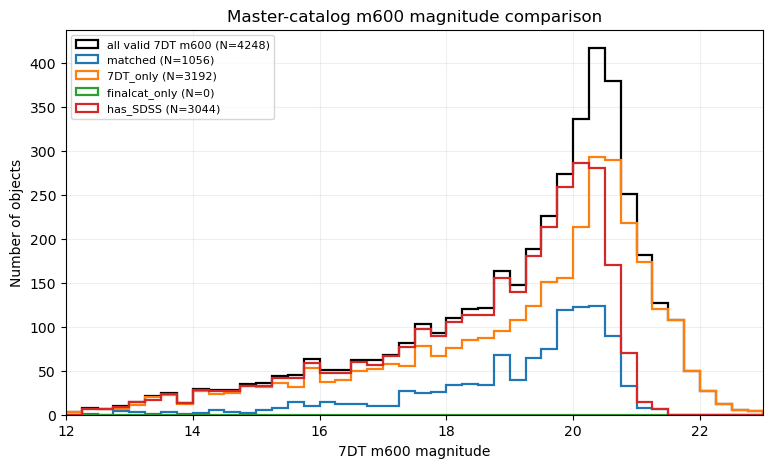

saved histograms for 20 bands to /Users/mac_seo/Research_local/7DTonCOSMOS/output/COSMOS1/singlebandphot/matching/figures/depth_by_band/01_mag_histograms


In [3]:
# Magnitude histograms for every 7DT band (display: m600 only; all bands saved as PNG).
for band in BANDS_7DT:
    mag = _finite_column(master, f'{band}_mag')
    valid = np.isfinite(mag)
    conditions = {
        f'all valid 7DT {band}': valid,
        'matched': (master_class == 'matched') & valid,
        '7DT_only': (master_class == '7dt_only') & valid,
        'finalcat_only': (master_class == 'finalcat_only') & valid,
        'has_SDSS': has_sdss_flag & valid,
    }
    values = mag[valid]
    hist_range = (np.floor(np.nanpercentile(values, 0.5)), np.ceil(np.nanpercentile(values, 99.5)))
    bin_edges = np.arange(hist_range[0], hist_range[1] + 0.25, 0.25)
    fig, ax = plt.subplots(figsize=(9, 5))
    colors = {'matched': 'C0', '7DT_only': 'C1', 'finalcat_only': 'C2', 'has_SDSS': 'C3'}
    ax.hist(values, bins=bin_edges, histtype='step', color='black', linewidth=1.6,
            label=f'all valid 7DT {band} (N={np.count_nonzero(valid)})')
    for key, color in colors.items():
        ax.hist(mag[conditions[key]], bins=bin_edges, histtype='step', linewidth=1.6,
                color=color, label=f'{key} (N={np.count_nonzero(conditions[key])})')
    ax.set_xlim(*hist_range)
    ax.set_xlabel(f'7DT {band} magnitude')
    ax.set_ylabel('Number of objects')
    ax.set_title(f'Master-catalog {band} magnitude comparison')
    ax.legend(fontsize=8); ax.grid(alpha=0.2)
    fig.savefig(HIST_DIR / f'{band}_mag_histogram.png', dpi=150, bbox_inches='tight')
    if band == 'm600':
        print(f'{band} histogram counts:')
        for name, cond in conditions.items():
            print(f'{name:>20s}: N = {np.count_nonzero(cond)}')
        plt.show()
    else:
        plt.close(fig)
print(f'saved histograms for {len(BANDS_7DT)} bands to {HIST_DIR}')


## m600 magnitude-S/N depth diagnostics

Sample is `7DT_only` union `matched`; S/N is `1.0857 / mag_err`. All bands are saved; `m600` is shown with full and `0 <= S/N <= 10` rows.


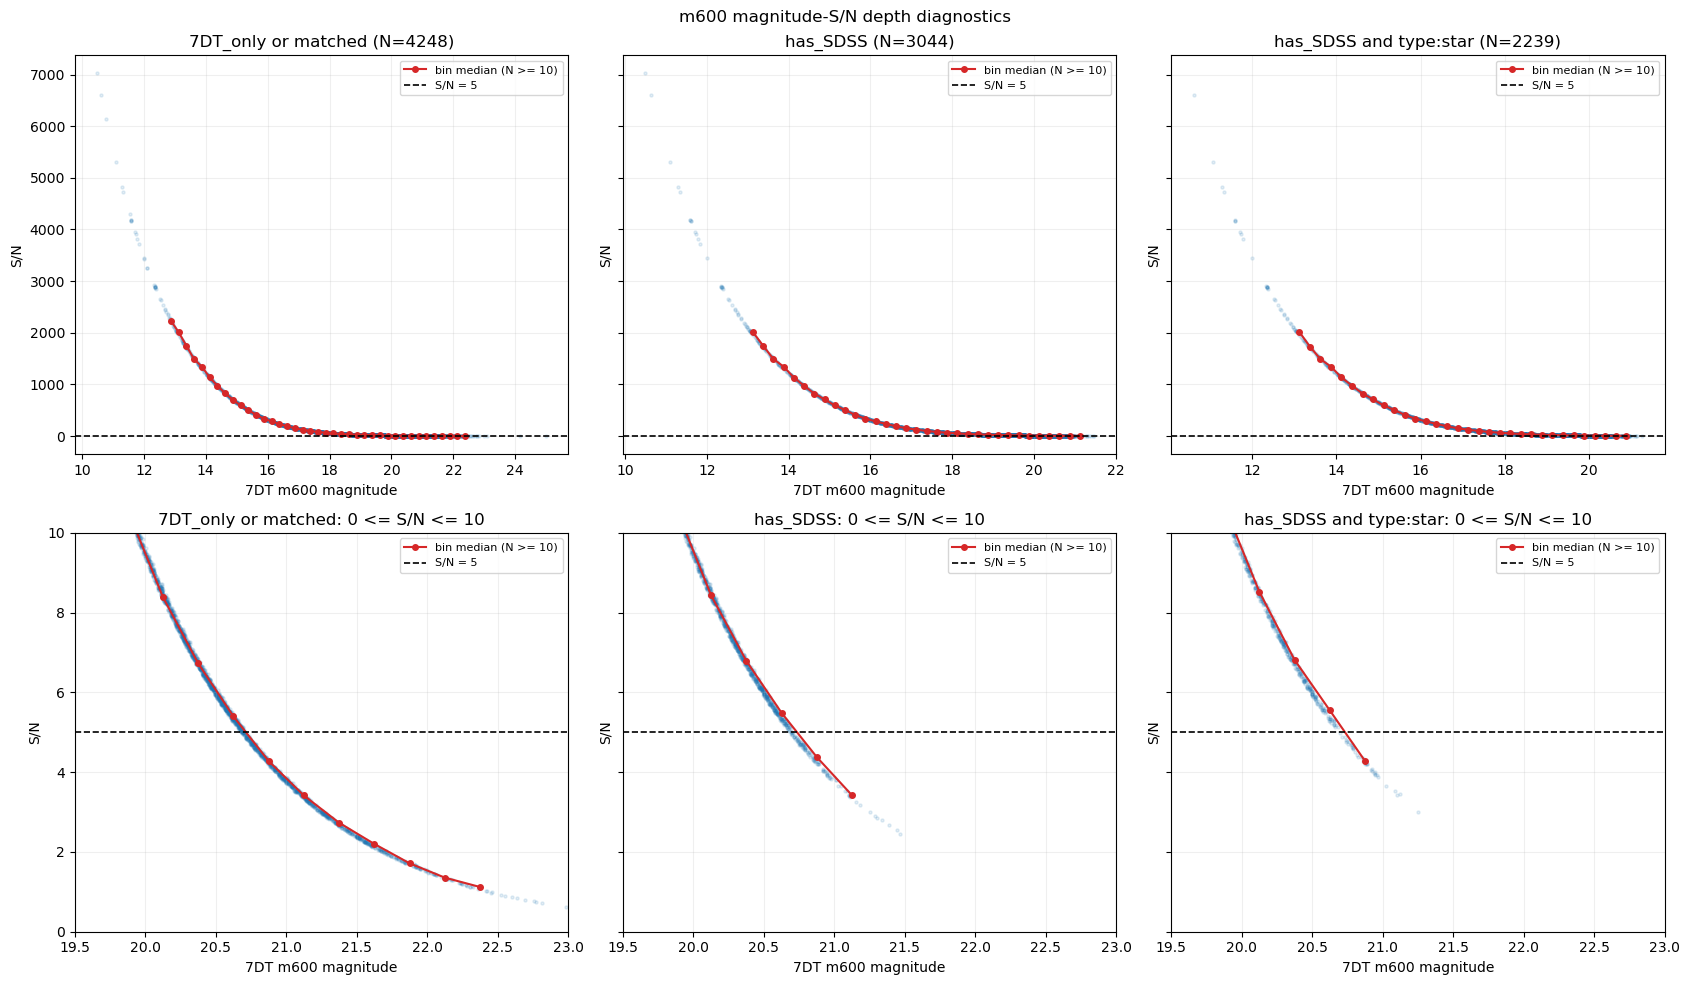

Magnitude-S/N population counts:
     7DT_only or matched: N = 4248
                has_SDSS: N = 3044
  has_SDSS and type:star: N = 2239


saved magnitude-S/N figures for 20 bands to /Users/mac_seo/Research_local/7DTonCOSMOS/output/COSMOS1/singlebandphot/matching/figures/depth_by_band/02_mag_snr


In [4]:
# Magnitude-S/N diagnostics for every 7DT band (display: m600 only; all bands saved as PNG).
def _depth_figure(band, mag, snr, base, save_path=None, show=False):
    conds = {
        '7DT_only or matched': base,
        'has_SDSS': base & has_sdss_flag,
        'has_SDSS and type:star': base & sdss_star,
    }
    bins = np.arange(np.floor(np.nanmin(mag[base])), np.ceil(np.nanmax(mag[base])) + 0.25, 0.25)
    fig, axes = plt.subplots(2, 3, figsize=(17, 10), sharey='row')
    crop = mag[base & (snr >= 0) & (snr <= 10)]
    crop_xlim = (np.floor(np.nanpercentile(crop, 0.5) * 2) / 2, np.ceil(np.nanpercentile(crop, 99.5) * 2) / 2)
    for col, (name, cond) in enumerate(conds.items()):
        x, y = mag[cond], snr[cond]
        for row in range(2):
            ax = axes[row, col]
            ax.scatter(x, y, s=5, alpha=0.12, color='C0', rasterized=True)
            centers, medians = [], []
            for left, right in zip(bins[:-1], bins[1:]):
                sel = (x >= left) & (x < right)
                if np.count_nonzero(sel) >= 10:
                    centers.append((left + right) / 2)
                    medians.append(np.nanmedian(y[sel]))
            ax.plot(centers, medians, 'o-', color='C3', markersize=4, linewidth=1.5, label='bin median (N >= 10)')
            ax.axhline(5, color='black', linestyle='--', linewidth=1.2, label='S/N = 5')
            ax.set_xlabel(f'7DT {band} magnitude')
            ax.grid(alpha=0.2)
            ax.legend(fontsize=8)
        axes[0, col].set_title(f'{name} (N={np.count_nonzero(cond)})')
        axes[0, col].set_ylabel('S/N')
        axes[1, col].set_ylim(0, 10)
        axes[1, col].set_xlim(*crop_xlim)
        axes[1, col].set_title(f'{name}: 0 <= S/N <= 10')
        axes[1, col].set_ylabel('S/N')
    fig.suptitle(f'{band} magnitude-S/N depth diagnostics')
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    if show:
        plt.show()
    else:
        plt.close(fig)
    return conds

for band in BANDS_7DT:
    mag = _finite_column(master, f'{band}_mag')
    err = _finite_column(master, f'{band}_mag_err')
    snr = 1.0857 / err
    valid = np.isfinite(mag)
    base = np.isin(master_class, ['7dt_only', 'matched']) & valid & np.isfinite(snr) & (err > 0)
    conds = _depth_figure(band, mag, snr, base, save_path=SNR_DIR / f'{band}_mag_snr.png', show=(band == 'm600'))
    if band == 'm600':
        print('Magnitude-S/N population counts:')
        for name, cond in conds.items():
            print(f'{name:>24s}: N = {np.count_nonzero(cond)}')
print(f'saved magnitude-S/N figures for {len(BANDS_7DT)} bands to {SNR_DIR}')


## SDSS versus 7DT consistency (nearest band)

Each 7DT band is compared with its nearest SDSS band. All bands are saved; `m600` is shown.


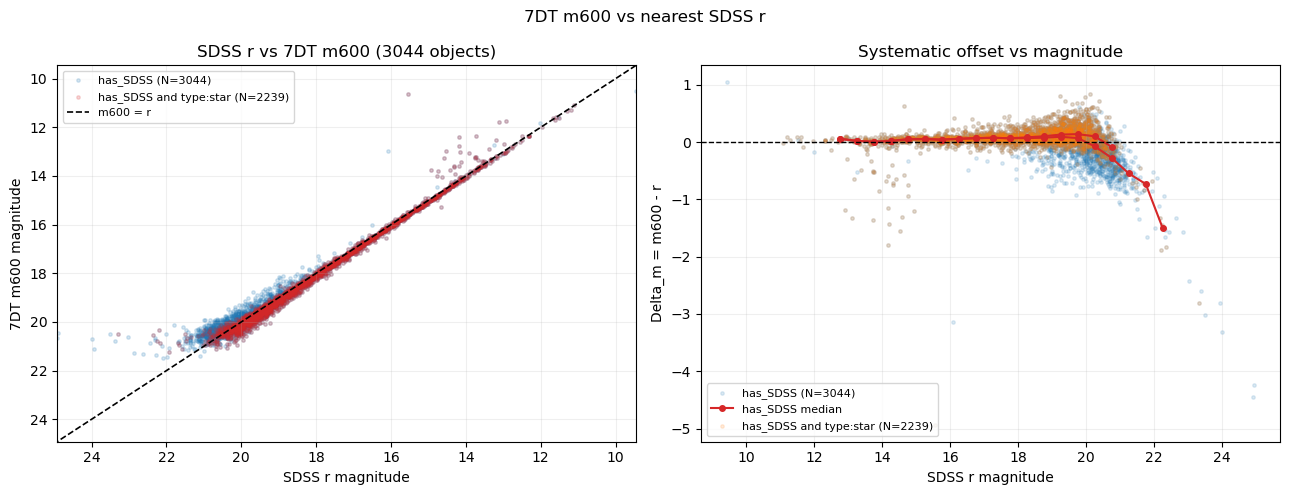

band  sdss  N_all  med_all  std_all  mad_all  N_star  med_star  std_star  mad_star
m400     u   1576  -0.7091  0.4683  0.2784   1398  -0.6977  0.3511  0.2639
m425     g   2688  +0.4302  0.4530  0.3659   2031  +0.5199  0.4027  0.3387
m450     g   2338  +0.0746  0.3236  0.1361   1949  +0.0901  0.2389  0.1082
m475     g   3624  -0.1485  0.2934  0.1675   2539  -0.1114  0.2327  0.1111
m500     g   3467  -0.1905  0.3278  0.1924   2514  -0.1440  0.2580  0.1097
m525     g   5051  -0.5109  0.3510  0.3701   3056  -0.3273  0.2913  0.2288
m550     r   2719  +0.2436  0.3586  0.2474   2132  +0.3074  0.2951  0.2218
m575     r   4430  +0.0981  0.3226  0.2176   2831  +0.1568  0.2461  0.1355
m600     r   3044  +0.0364  0.3466  0.1590   2239  +0.0689  0.2377  0.0960
m625     r   4570  -0.0733  0.3414  0.2113   2840  -0.0128  0.2335  0.0868
m650     r   2799  -0.1812  0.3129  0.2280   2241  -0.1200  0.2495  0.1588
m675     r   5994  -0.2679  0.3262  0.2613   3405  -0.1616  0.2511  0.1346
m700     i   3546

In [5]:
# SDSS consistency for every 7DT band vs nearest SDSS band (display: m600 only; all bands saved as PNG).
import math
rows = []
for band in BANDS_7DT:
    sband = BAND_SDSS_MATCH[band]
    mag = _finite_column(master, f'{band}_mag')
    sdss_mag = _finite_column(master, f'sdss_psfMag_{sband}')
    valid = has_sdss_flag & np.isfinite(mag) & np.isfinite(sdss_mag)
    star_sel = valid & sdss_star
    delta = mag - sdss_mag
    def _stats(v):
        v = v[np.isfinite(v)]
        if len(v) == 0:
            return (0, math.nan, math.nan, math.nan)
        med = float(np.nanmedian(v))
        return (len(v), med, float(np.nanstd(v)), float(1.4826 * np.nanmedian(np.abs(v - med))))
    n_all, med_all, std_all, mad_all = _stats(delta[valid])
    n_star, med_star, std_star, mad_star = _stats(delta[star_sel])
    rows.append((band, sband, n_all, med_all, std_all, mad_all, n_star, med_star, std_star, mad_star))
    # Scatter + Delta plots.
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
    for cond, label, color in [(valid, 'has_SDSS', 'C0'), (star_sel, 'has_SDSS and type:star', 'C3')]:
        axes[0].scatter(sdss_mag[cond], mag[cond], s=6, alpha=0.18, color=color,
                        label=f'{label} (N={np.count_nonzero(cond)})', rasterized=True)
    lo = float(np.nanmin(np.concatenate([sdss_mag[valid], mag[valid]])))
    hi = float(np.nanmax(np.concatenate([sdss_mag[valid], mag[valid]])))
    axes[0].plot([lo, hi], [lo, hi], 'k--', linewidth=1.2, label=f'{band} = {sband}')
    axes[0].set(xlim=(lo, hi), ylim=(lo, hi), xlabel=f'SDSS {sband} magnitude', ylabel=f'7DT {band} magnitude')
    axes[0].invert_xaxis(); axes[0].invert_yaxis()
    axes[0].set_title(f'SDSS {sband} vs 7DT {band} ({n_all} objects)')
    axes[0].grid(alpha=0.2); axes[0].legend(fontsize=8)
    for cond, label in [(valid, 'has_SDSS'), (star_sel, 'has_SDSS and type:star')]:
        x, d = sdss_mag[cond], delta[cond]
        axes[1].scatter(x, d, s=6, alpha=0.15, label=f'{label} (N={np.count_nonzero(cond)})', rasterized=True)
        bins = np.arange(np.floor(np.nanmin(x)), np.ceil(np.nanmax(x)) + 0.5, 0.5)
        centers, medians = [], []
        for left, right in zip(bins[:-1], bins[1:]):
            sel = (x >= left) & (x < right)
            if np.count_nonzero(sel) >= 10:
                centers.append((left + right) / 2)
                medians.append(np.nanmedian(d[sel]))
        axes[1].plot(centers, medians, 'o-', color='C3', markersize=4, label=f'{label} median' if label == 'has_SDSS' else None)
    axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[1].set(xlabel=f'SDSS {sband} magnitude', ylabel=f'Delta_m = {band} - {sband}')
    axes[1].set_title(f'Systematic offset vs magnitude')
    axes[1].grid(alpha=0.2); axes[1].legend(fontsize=8)
    fig.suptitle(f'7DT {band} vs nearest SDSS {sband}')
    fig.tight_layout()
    fig.savefig(CONSISTENCY_DIR / f'{band}_vs_sdss_{sband}_consistency.png', dpi=150, bbox_inches='tight')
    if band == 'm600':
        plt.show()
    else:
        plt.close(fig)
print('band  sdss  N_all  med_all  std_all  mad_all  N_star  med_star  std_star  mad_star')
for r in rows:
    print(f"{r[0]}  {r[1]:>4s}  {r[2]:5d}  {r[3]:+.4f}  {r[4]:.4f}  {r[5]:.4f}  {r[6]:5d}  {r[7]:+.4f}  {r[8]:.4f}  {r[9]:.4f}")
print(f'saved SDSS-consistency figures for {len(BANDS_7DT)} bands to {CONSISTENCY_DIR}')


In [6]:
def plot_ImageAndDetectedSources(
    image, cat, center_point=None, length=None,
    x_column='master_x', y_column='master_y',
    source_color='red', title=None, output_filename=None,
):
    '''Plot an image cutout and catalog source positions.'''
    required = {x_column, y_column}
    missing = required.difference(cat.colnames)
    if missing:
        raise KeyError(f'Catalog is missing required columns: {sorted(missing)}')
    if (center_point is None) != (length is None):
        raise ValueError('center_point and length must be provided together.')
    if center_point is None:
        xmin, ymin, xmax, ymax = 0, 0, image.shape[1], image.shape[0]
    else:
        half = float(length) / 2.0
        xmin = max(0, int(np.floor(center_point[0] - half)))
        xmax = min(image.shape[1], int(np.ceil(center_point[0] + half)))
        ymin = max(0, int(np.floor(center_point[1] - half)))
        ymax = min(image.shape[0], int(np.ceil(center_point[1] + half)))
    if xmax <= xmin or ymax <= ymin:
        raise ValueError('The requested cutout is empty.')
    x = np.ma.filled(cat[x_column], np.nan).astype(float)
    y = np.ma.filled(cat[y_column], np.nan).astype(float)
    finite = np.isfinite(x) & np.isfinite(y) & (x >= xmin) & (x < xmax) & (y >= ymin) & (y < ymax)
    figure, axis = plt.subplots(figsize=(10, 10))
    image_plot = image[ymin:ymax, xmin:xmax]
    axis.imshow(image_plot, origin='lower', cmap='gray', norm=ImageNormalize(image_plot, interval=ZScaleInterval()), extent=[xmin, xmax, ymin, ymax])
    axis.scatter(x[finite], y[finite], s=36, facecolors='none', edgecolors=source_color, linewidths=0.8, label=f'detected sources ({int(finite.sum())})', rasterized=True)
    if center_point is not None:
        axis.axhline(center_point[1], color='cyan', linestyle='--', linewidth=0.8)
        axis.axvline(center_point[0], color='cyan', linestyle='--', linewidth=0.8)
    axis.set(xlabel='X pixel', ylabel='Y pixel')
    if title is not None:
        axis.set_title(title)
    axis.legend(loc='upper right')
    figure.tight_layout()
    if output_filename is not None:
        figure.savefig(output_filename, dpi=160, bbox_inches='tight')
    return figure, axis, int(finite.sum())


In [7]:
def plot_SourceImgFromCatalog(cat, image=None, pixel_range=None, source_id=None):
    # Plot a catalog on the detection image, optionally centered on one source.
    if image is None:
        image = detection_image
    if len(cat) == 0:
        raise ValueError("The input catalog is empty.")
    required = {"master_id", "master_x", "master_y"}
    missing = required.difference(cat.colnames)
    if missing:
        raise KeyError(f"Catalog is missing required columns: {sorted(missing)}")
    if pixel_range is not None and (not np.isfinite(pixel_range) or pixel_range <= 0):
        raise ValueError("pixel_range must be None or a positive number.")

    master_ids = np.asarray(cat["master_id"], dtype=np.int64)
    if source_id is None:
        rng = np.random.default_rng()
        selected_index = int(rng.integers(len(cat)))
    else:
        matches = np.flatnonzero(master_ids == int(source_id))
        if len(matches) == 0:
            raise KeyError(f"master_id={source_id} is not present in the catalog.")
        selected_index = int(matches[0])

    x_all = np.ma.filled(cat["master_x"], np.nan).astype(float)
    y_all = np.ma.filled(cat["master_y"], np.nan).astype(float)
    selected_x = float(x_all[selected_index])
    selected_y = float(y_all[selected_index])
    if not np.isfinite(selected_x) or not np.isfinite(selected_y):
        raise ValueError("The selected source has a non-finite pixel position.")

    if pixel_range is None:
        xmin, xmax = 0, image.shape[1]
        ymin, ymax = 0, image.shape[0]
    else:
        center_x = int(round(selected_x - 1))
        center_y = int(round(selected_y - 1))
        half = int(round(pixel_range))
        xmin = max(0, center_x - half)
        xmax = min(image.shape[1], center_x + half + 1)
        ymin = max(0, center_y - half)
        ymax = min(image.shape[0], center_y + half + 1)

    finite = np.isfinite(x_all) & np.isfinite(y_all)
    in_view = finite & (
        (x_all - 1 >= xmin) & (x_all - 1 < xmax)
        & (y_all - 1 >= ymin) & (y_all - 1 < ymax)
    )
    crop = image[ymin:ymax, xmin:xmax]
    norm = ImageNormalize(image, interval=ZScaleInterval())
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(
        crop,
        origin="lower",
        cmap="gray",
        norm=norm,
        extent=[xmin + 1, xmax + 1, ymin + 1, ymax + 1],
    )

    default_color = "tab:red"
    class_colors = {"matched": "purple", "7dt_only": "tab:red", "finalcat_only": "tab:blue"}
    if "master_class" in cat.colnames:
        classes = np.asarray(cat["master_class"]).astype(str)
    else:
        classes = np.full(len(cat), "source", dtype="U16")
    for index in np.flatnonzero(in_view):
        ax.scatter(
            x_all[index], y_all[index], s=24, facecolors="none",
            edgecolors=class_colors.get(classes[index], default_color), linewidths=0.8,
        )

    ax.scatter(
        selected_x, selected_y, marker="+", s=180, color="cyan", linewidths=1.5,
        label=f"master_id={master_ids[selected_index]}",
    )
    ax.set_xlabel("X pixel")
    ax.set_ylabel("Y pixel")
    title_class = classes[selected_index]
    view_label = "whole image" if pixel_range is None else f"pixel_range={pixel_range}"
    ax.set_title(f"{title_class}: master_id={master_ids[selected_index]} ({view_label})")
    ax.legend(loc="upper right")
    fig.tight_layout()
    plt.show()
    return fig, ax, int(master_ids[selected_index])



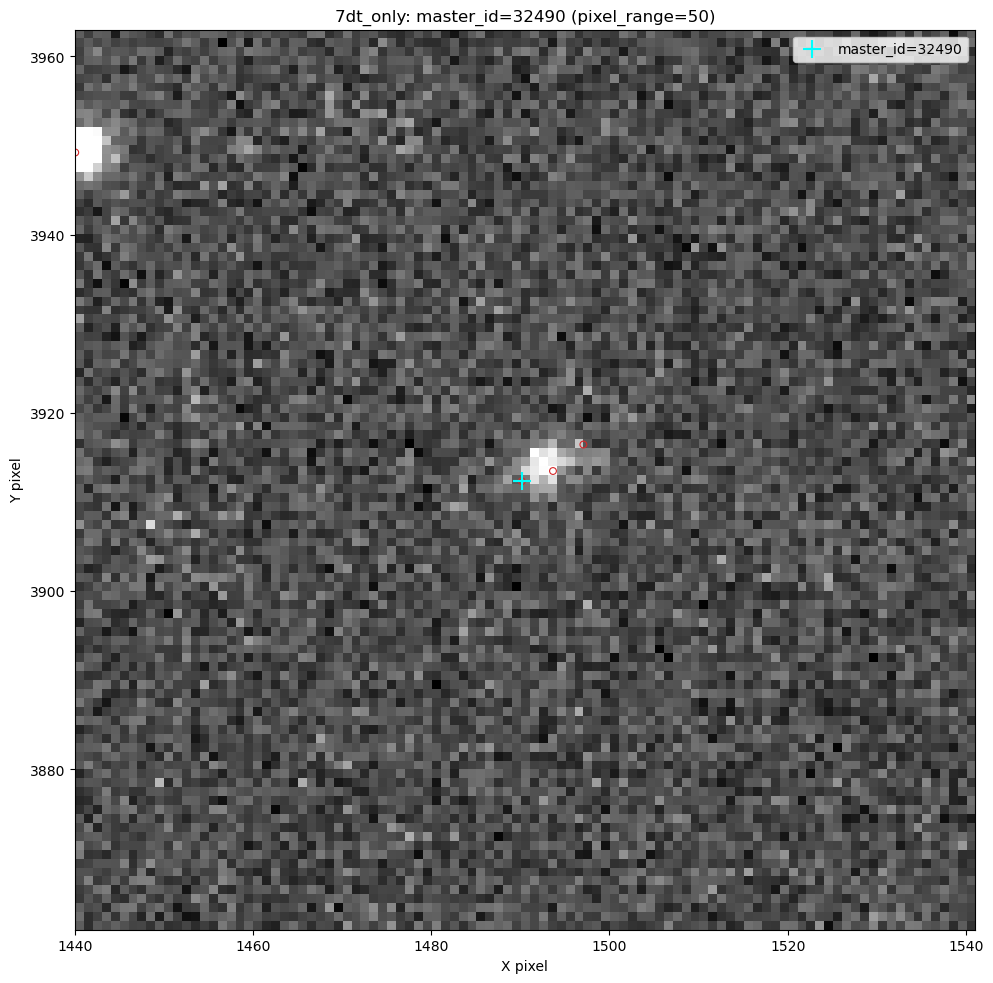

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': '7dt_only: master_id=32490 (pixel_range=50)'}, xlabel='X pixel', ylabel='Y pixel'>,
 32490)

In [8]:
plot_SourceImgFromCatalog(cat_7dt_only, pixel_range=50)
